# Example of Reconstruction of spectral data downloaded from PILOT

### Download experimental data from PILOT - for more options see ``download_data.py``

In [5]:
from pathlib import Path
from spyrit.misc.load_data import download_girder

# where to save data
destination = Path("./")
print("Copying folder in:", destination)

# download data from the Pilot warehouse
url_pilot = "https://pilot-warehouse.creatis.insa-lyon.fr/api/v1"

datasets = [

    {
        "subfolder": "data/opticalTuningCat3",
        "comment": "SPIHIM/data/setup_v2.02026-06-19_optical_tuning/",
        "files": [
            "6a354d7cc392eb77b9ec162b",  # obj_cat3_..._zoom_x2/spectral_data.npz
            "6a354d65c392eb77b9ec131d",  # metadata
            "6a354d65c392eb77b9ec131a",  # had
        ],
    },
]

for ds in datasets:
    data_subfolder = Path(ds["subfolder"])
    try:
        download_girder(url_pilot, ds["files"], data_subfolder)
    except Exception as e:
        print(f"Unable to download data from the Pilot warehouse ({ds['subfolder']})")
        print(e)

Copying folder in: .
File already exists at data\opticalTuningCat3\spectral_data.npz
File already exists at data\opticalTuningCat3\metadata.json
File already exists at data\opticalTuningCat3\had_reco.npz


### Load data

In [6]:
import numpy as np
from tools import read_acquisitionData

# folder when downloaded datd is stored
data_folder = Path("data/opticalTuningCat3") 

# load raw spectral data
spectral_data = np.load(data_folder / f"spectral_data.npz", allow_pickle=True)["spectral_data"]

# metadata
meta_path = data_folder / "metadata.json"
meta = read_acquisitionData(meta_path)
acquisition_parameters = meta['acquisition_params']

# reqd useful info from metadata
wavelengths = acquisition_parameters.wavelengths # list of wavelengths measured

w = acquisition_parameters.pattern_dimension_x   # width of pattern
h = acquisition_parameters.pattern_dimension_y   # height of pattern
P = acquisition_parameters.pattern_amount        # number of (split) patterns applied

order = acquisition_parameters.patterns # order of acquisition patterns
ind = np.array(order)                   # corresponding acquisition row indices


print(f"Spectral data shape: {spectral_data.shape}")
print(f"Spectral data dtype: {spectral_data.dtype}")
print(f"Wavelength range: {wavelengths.min():.2f} - {wavelengths.max():.2f} nm "
      f"({len(wavelengths)} points)")
print(f"Pattern dimensions: {h} x {w}")
print(f"Number of patterns applied: {P}")


Spectral data shape: (165, 608, 256)
Spectral data dtype: float64
Wavelength range: 455.27 - 638.01 nm (608 points)
Pattern dimensions: 128 x 128
Number of patterns applied: 256


### Format raw spectral data: 
- reorder acquisition rows to cronological; 
- bin spatial / spectral dimensions
- crop
- etc... depends on specific aquisition.

For ``OpticalTuningCat3`` , the spatial dimension is cropped; and no further binning is applied.

For further formatting options, see ``format_data.py``



In [8]:
import matplotlib.pyplot as plt
# for opticalTuningCat, crop from 165 to 128:
spectral_data = spectral_data[20:148, :,:]

N,L,P = spectral_data.shape
K = P//2 

# reorder rows
m_reordered = np.zeros((N,L,P)) # create space first
m_reordered[:,:,ind]  = spectral_data # place rows of m_unsplit following order of ind :)

# if already in asceneding order, should be zeros:
# check = m_reordered - spectral_data
# print(check)

Plot first measure

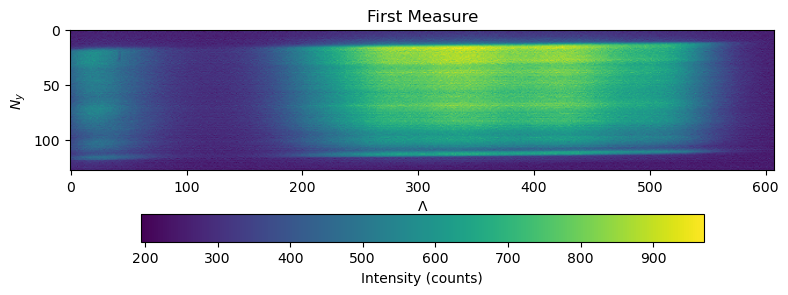

In [9]:

fig, ax = plt.subplots(figsize=(8, 3))

im = ax.imshow(spectral_data[:, :, 0], aspect='auto', cmap='viridis')
ax.set_title("First Measure")
ax.set_xlabel(r'$\Lambda$')
ax.set_ylabel(r'$N_y$')

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.2, shrink=0.8)
cbar.set_label("Intensity (counts)")

fig.tight_layout()
plt.show()


## Direct Reconstruction

In [10]:

import torch 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

m = np.moveaxis(m_reordered,0,1) # move spectral axis to front 
m = torch.from_numpy(m).to(torch.float32).to(device)

print("Shape of formatted measurements: ", m.shape)

Shape of formatted measurements:  torch.Size([608, 128, 256])


The experimental parameters are calculated and saved to folder ``CalibrationData.py`` by running ``dark_estimation.py`` and ``conversion_gain_estim.py``,
or the folder of resulting images can be downloaded directly from the PILOT.

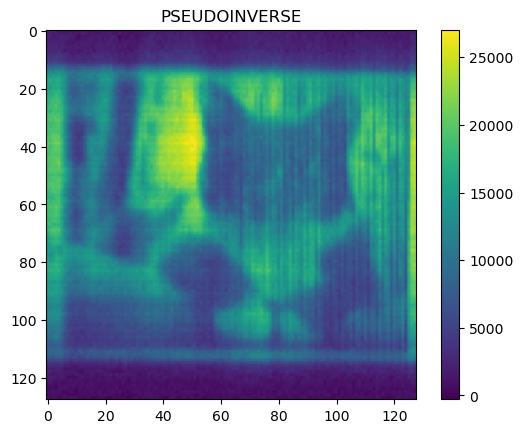

In [ ]:
from spyrit.core.recon import PinvNet 
from spyrit.core.meas import Linear
from spyrit.misc.walsh_hadamard import walsh_matrix
from spyrit.core.prep import Unsplit
import matplotlib.pyplot as plt

calib_data = Path('./CalibrationData')

# choose the conversion gain matching the acquisition configuration used (integration time, camera gain)
gamma = 0.1152 #  torch.from_numpy(np.load(calib_data / "bright" / "slope_g3_bin_x3_12.04.npy")).to(device)


# generate hadamard acquisition matrix and create linear operator
H = walsh_matrix(K)
H = torch.from_numpy(H).to(device)
meas_op = Linear(H, device=device) 

# only preprocessing considered is unsplitting
prep_op = Unsplit()
model = PinvNet(meas_op, prep=prep_op, store_H_pinv = True, device = device) 
model.eval()
model = model.to(device)


with torch.no_grad():

    x_hat = model.reconstruct(m/gamma)
    x_pinv = x_hat.detach().cpu().numpy().squeeze()

del model 

plt.imshow(x_pinv.sum(0))
plt.title("PSEUDOINVERSE")
plt.colorbar()


Plot some channels

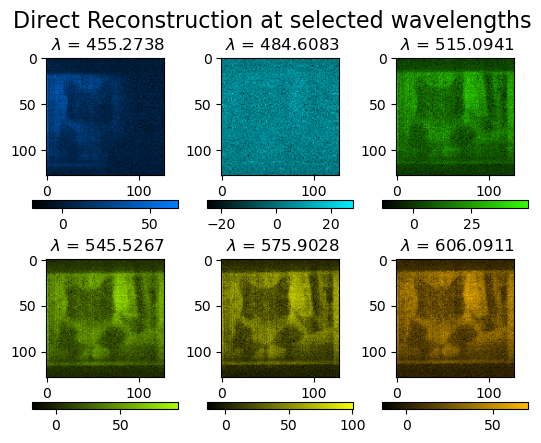

In [16]:
import re
from spyrit.misc.color import wavelength_to_colormap
x_recon = x_pinv


meta_path = data_folder / "metadata.json"
meta = read_acquisitionData(meta_path)
acquisition_parameters = meta['acquisition_params']


wavelengths = acquisition_parameters.wavelengths # list of wavelengths measured
cmap = wavelength_to_colormap(wavelengths[0], gamma=0.6)


fig, axs = plt.subplots(2, 3)

# Global title
fig.suptitle("Direct Reconstruction at selected wavelengths", fontsize=16)
im = axs[0,0].imshow(np.fliplr(x_recon[0,:,:]), cmap=cmap)
axs[0,0].set_title( rf" $\lambda$ = {wavelengths[0]}")
plt.colorbar(im, ax = axs[0,0], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[100], gamma=0.6)
im = axs[0,1].imshow(np.fliplr(x_recon[100,:,:]), cmap=cmap)
axs[0,1].set_title( rf" $\lambda$ = {wavelengths[100]}")
plt.colorbar(im, ax = axs[0,1], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[200], gamma=0.6)
im = axs[0,2].imshow(np.fliplr(x_recon[200,:,:]), cmap=cmap)
axs[0,2].set_title( rf" $\lambda$ = {wavelengths[200]}")
plt.colorbar(im, ax = axs[0,2], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[300], gamma=0.6)
im = axs[1,0].imshow(np.fliplr(x_recon[300,:,:]), cmap=cmap)
axs[1,0].set_title( rf" $\lambda$ = {wavelengths[300]}")
plt.colorbar(im, ax = axs[1,0], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[400], gamma=0.6)
im = axs[1,1].imshow(np.fliplr(x_recon[400,:,:]), cmap=cmap)
axs[1,1].set_title( rf" $\lambda$ = {wavelengths[400]}")
plt.colorbar(im, ax = axs[1,1], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[500], gamma=0.6)
im = axs[1,2].imshow(np.fliplr(x_recon[500,:,:]), cmap=cmap)
axs[1,2].set_title( rf" $\lambda$ = {wavelengths[500]}")
plt.colorbar(im, ax = axs[1,2], orientation = 'horizontal')



## Tikhonov Reconstruction

Run ``covariance_prior`` to calculate the covariance matrix used as prior if not already saved to ``data`` folder. 


In [ ]:
# load dark params
# mudark_image = torch.from_numpy(np.load(calib_data / "dark" / "mu_dark_image_binned_x3_1.0_12.04.npy")).to(device)
# sigdark_image = torch.from_numpy(np.load(calib_data / "dark" / "sigma_dark_image_binned_x3_1.0_12.04.npy")).to(device)

# mudark = mudark_image.mean()
# sigdark =sigdark_image.mean()

sigdark = 4.3782
mudark = 243.4177
# load Sigma
image_cov = np.load('data/Cov_1_128x128.npy')
Sigma = torch.from_numpy(image_cov).to(device)



Pre trained model can be downloaded from PILOT; or retrained by running ``train.py``, which will save the trained model to folder ``model``

Model Loaded: model/TIKHO_UNET_128x128_K=128_alpha100_20epochs.pth


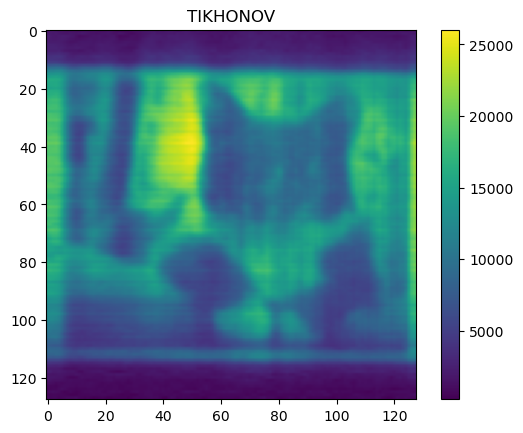

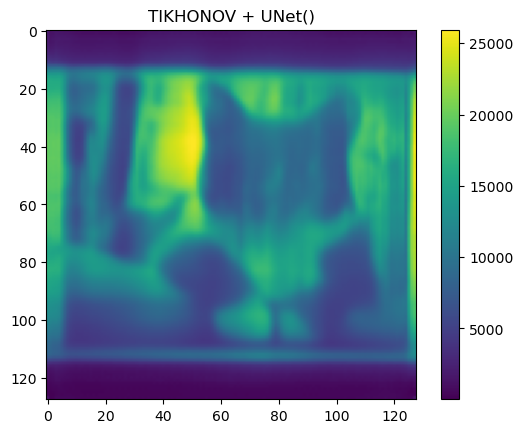

In [20]:
from spyrit.core.prep import UnsplitRescale
from spyrit.core.recon import TikhoNet

# normalisation parameter estimated from pseudoinverse
alpha_est = x_pinv.reshape(L, N*N).max(-1)
alpha_est = torch.from_numpy(alpha_est).to(device)

# Sigma calculation (measurement covariance)
z = (m[..., 0::2] + m[..., 1::2]) # .detach().cpu() 
cov_meas = gamma * (z - 2*mudark) + 2 * sigdark**2   
cov_meas = cov_meas.to(device)
norm = gamma*alpha_est[:,None, None]
cov_meas = cov_meas / norm**2
Gamma = torch.diag_embed(cov_meas)


# load net
from spyrit.core.nnet import Unet
from spyrit.core.recon import OrderedDict, TikhoNet, PinvNet
from spyrit.core.train import load_net
import torch.nn as nn
from spyrit.core.prep import Rerange

title = f'model/TIKHO_UNET_128x128_K=128_alpha100_20epochs.pth'

denoiser = torch.nn.Sequential(OrderedDict({"denoi": Unet()}))
load_net(title, denoiser, device, False)

prep_op = UnsplitRescale(alpha_est[:,None, None])
model = TikhoNet(meas_op, prep = prep_op , sigma = Sigma, denoi = denoiser, device = device) 
model.eval()
model = model.to(device)

with torch.no_grad():

    m_hat = model.prep(m/gamma)
    x_hat = model.tikho(m_hat, Gamma)

    x_d = model.denoi(x_hat.reshape(L, 1, 128, 128))
    x_tiko = x_hat.detach().cpu().numpy().squeeze()
    x_tikonet = x_d.detach().cpu().numpy().squeeze()
del model

x_tikonet_denorm = x_tikonet*alpha_est.detach().cpu().numpy().squeeze()[:,None, None]
x_tiko_denorm = x_tiko*alpha_est.detach().cpu().numpy().squeeze()[:,None, None]

plt.imshow(x_tiko_denorm.sum(0))
plt.title("TIKHONOV")
plt.colorbar()

plt.figure()
plt.imshow(x_tikonet_denorm.sum(0))
plt.title("TIKHONOV + UNet()")
plt.colorbar()



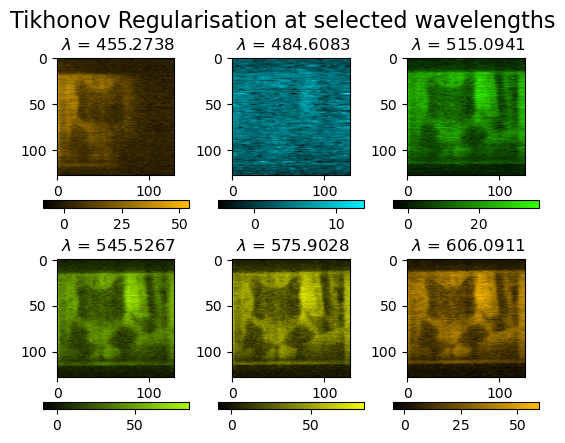

<Figure size 640x480 with 0 Axes>

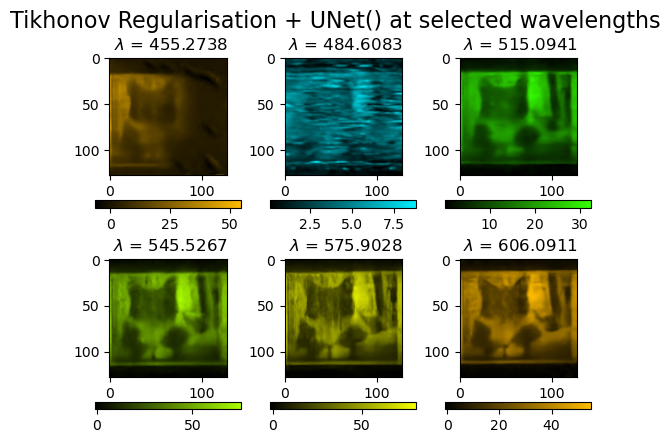

In [21]:
x_recon = x_tiko_denorm #x_tikonet_denorm #x_pinv

fig, axs = plt.subplots(2, 3)

# Global title
fig.suptitle("Tikhonov Regularisation at selected wavelengths", fontsize=16)
im = axs[0,0].imshow(np.fliplr(x_recon[0,:,:]), cmap=cmap)
axs[0,0].set_title( rf" $\lambda$ = {wavelengths[0]}")
plt.colorbar(im, ax = axs[0,0], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[100], gamma=0.6)
im = axs[0,1].imshow(np.fliplr(x_recon[100,:,:]), cmap=cmap)
axs[0,1].set_title( rf" $\lambda$ = {wavelengths[100]}")
plt.colorbar(im, ax = axs[0,1], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[200], gamma=0.6)
im = axs[0,2].imshow(np.fliplr(x_recon[200,:,:]), cmap=cmap)
axs[0,2].set_title( rf" $\lambda$ = {wavelengths[200]}")
plt.colorbar(im, ax = axs[0,2], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[300], gamma=0.6)
im = axs[1,0].imshow(np.fliplr(x_recon[300,:,:]), cmap=cmap)
axs[1,0].set_title( rf" $\lambda$ = {wavelengths[300]}")
plt.colorbar(im, ax = axs[1,0], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[400], gamma=0.6)
im = axs[1,1].imshow(np.fliplr(x_recon[400,:,:]), cmap=cmap)
axs[1,1].set_title( rf" $\lambda$ = {wavelengths[400]}")
plt.colorbar(im, ax = axs[1,1], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[500], gamma=0.6)
im = axs[1,2].imshow(np.fliplr(x_recon[500,:,:]), cmap=cmap)
axs[1,2].set_title( rf" $\lambda$ = {wavelengths[500]}")
plt.colorbar(im, ax = axs[1,2], orientation = 'horizontal')



plt.figure()

x_recon = x_tikonet_denorm #x_tikonet_denorm #x_pinv

fig, axs = plt.subplots(2, 3)

# Global title
fig.suptitle("Tikhonov Regularisation + UNet() at selected wavelengths", fontsize=16)
im = axs[0,0].imshow(np.fliplr(x_recon[0,:,:]), cmap=cmap)
axs[0,0].set_title( rf" $\lambda$ = {wavelengths[0]}")
plt.colorbar(im, ax = axs[0,0], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[100], gamma=0.6)
im = axs[0,1].imshow(np.fliplr(x_recon[100,:,:]), cmap=cmap)
axs[0,1].set_title( rf" $\lambda$ = {wavelengths[100]}")
plt.colorbar(im, ax = axs[0,1], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[200], gamma=0.6)
im = axs[0,2].imshow(np.fliplr(x_recon[200,:,:]), cmap=cmap)
axs[0,2].set_title( rf" $\lambda$ = {wavelengths[200]}")
plt.colorbar(im, ax = axs[0,2], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[300], gamma=0.6)
im = axs[1,0].imshow(np.fliplr(x_recon[300,:,:]), cmap=cmap)
axs[1,0].set_title( rf" $\lambda$ = {wavelengths[300]}")
plt.colorbar(im, ax = axs[1,0], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[400], gamma=0.6)
im = axs[1,1].imshow(np.fliplr(x_recon[400,:,:]), cmap=cmap)
axs[1,1].set_title( rf" $\lambda$ = {wavelengths[400]}")
plt.colorbar(im, ax = axs[1,1], orientation = 'horizontal')

cmap = wavelength_to_colormap(wavelengths[500], gamma=0.6)
im = axs[1,2].imshow(np.fliplr(x_recon[500,:,:]), cmap=cmap)
axs[1,2].set_title( rf" $\lambda$ = {wavelengths[500]}")
plt.colorbar(im, ax = axs[1,2], orientation = 'horizontal')
